In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# FIPS 10-4 to Country Name mapping
fips_to_country = {
    'AA': 'Aruba',
    'AC': 'Antigua and Barbuda',
    'AD': 'Akrotiri',
    'AE': 'United Arab Emirates',
    'AF': 'Afghanistan',
    'AG': 'Algeria',
    'AJ': 'Azerbaijan',
    'AL': 'Albania',
    'AM': 'Armenia',
    'AN': 'Andorra',
    'AO': 'Angola',
    'AQ': 'American Samoa',
    'AR': 'Argentina',
    'AS': 'Australia',
    'AT': 'Ashmore and Cartier Islands',
    'AU': 'Austria',
    'AV': 'Anguilla',
    'AY': 'Antarctica',
    'BA': 'Bahrain',
    'BB': 'Barbados',
    'BC': 'Botswana',
    'BD': 'Bermuda',
    'BE': 'Belgium',
    'BF': 'Bahamas',
    'BG': 'Bangladesh',
    'BH': 'Belize',
    'BK': 'Bosnia and Herzegovina',
    'BL': 'Bolivia',
    'BM': 'Burma',
    'BN': 'Benin',
    'BO': 'Belarus',
    'BP': 'Solomon Islands',
    'BQ': 'Navassa Island',
    'BR': 'Brazil',
    'BT': 'Bhutan',
    'BU': 'Bulgaria',
    'BV': 'Bouvet Island',
    'BX': 'Brunei',
    'BY': 'Burundi',
    'CA': 'Canada',
    'CB': 'Cambodia',
    'CD': 'Chad',
    'CE': 'Sri Lanka',
    'CF': 'Republic of the Congo',
    'CG': 'Democratic Republic of the Congo',
    'CH': 'China',
    'CI': 'Cile',
    'CJ': 'Cayman Islands',
    'CK': 'Cocos (Keeling) Islands',
    'CM': 'Cameroon',
    'CN': 'Comoros',
    'CO': 'Colombia',
    'CQ': 'Northern Mariana Islands',
    'CR': 'Coral Sea Islands',
    'CS': 'Costa Rica',
    'CT': 'Central African Republic',
    'CU': 'Cuba',
    'CV': 'Cape Verde',
    'CW': 'Cook Islands',
    'CY': 'Cyprus',
    'DA': 'Denmark',
    'DJ': 'Djibouti',
    'DO': 'Dominica',
    'DR': 'Dominican Republic',
    'EC': 'Ecuador',
    'EE': 'European Union',
    'EG': 'Egypt',
    'EI': 'Ireland',
    'EK': 'Equatorial Guinea',
    'EN': 'Estonia',
    'ER': 'Eritrea',
    'ES': 'El Salvador',
    'ET': 'Ethiopia',
    'EU': 'Europa Island',
    'EZ': 'Czechia',
    'FG': 'French Guiana',
    'FI': 'Finland',
    'FJ': 'Fiji',
    'FK': 'Falkland Islands',
    'FM': 'Micronesia',
    'FO': 'Faroe Islands',
    'FP': 'French Polynesia',
    'FR': 'France',
    'FS': 'French Southern and Antarctic Lands',
    'GA': 'Gambia',
    'GB': 'Gabon',
    'GG': 'Georgia',
    'GH': 'Ghana',
    'GI': 'Gibraltar',
    'GJ': 'Grenada',
    'GK': 'Guernsey',
    'GL': 'Greenland',
    'GM': 'Germany',
    'GO': 'Glorioso Islands',
    'GP': 'Guadeloupe',
    'GQ': 'Guam',
    'GR': 'Greece',
    'GT': 'Guatemala',
    'GV': 'Guinea',
    'GY': 'Guyana',
    'GZ': 'Palestine',
    'HA': 'Haiti',
    'HK': 'Hong Kong',
    'HM': 'Heard Island and McDonald Islands',
    'HO': 'Honduras',
    'HR': 'Croatia',
    'HU': 'Hungary',
    'IC': 'Iceland',
    'ID': 'Indonesia',
    'IM': 'Isle of Man',
    'IN': 'India',
    'IO': 'British Indian Ocean Territory',
    'IP': 'Clipperton Island',
    'IR': 'Iran',
    'IS': 'Israel',
    'IT': 'Italy',
    'IV': 'Côte d’Ivoire',
    'IZ': 'Iraq',
    'JA': 'Japan',
    'JE': 'Jersey',
    'JM': 'Jamaica',
    'JN': 'Jan Mayen',
    'JO': 'Jordan',
    'JU': 'Juan de Nova Island',
    'KE': 'Kenya',
    'KG': 'Kyrgyzstan',
    'KN': 'North Korea',
    'KR': 'Kiribati',
    'KS': 'South Korea',
    'KT': 'Christmas Island',
    'KU': 'Kuwait',
    'KV': 'Kosovo',
    'KZ': 'Kazakhstan',
    'LA': 'Laos',
    'LE': 'Lebanon',
    'LG': 'Latvia',
    'LH': 'Lithuania',
    'LI': 'Liberia',
    'LO': 'Slovakia',
    'LS': 'Lichtenstein',
    'LT': 'Lesotho',
    'LU': 'Luxembourg',
    'LY': 'Libya',
    'MA': 'Madagascar',
    'MB': 'Martinique',
    'MC': 'Macau',
    'MD': 'Moldova',
    'MF': 'Mayotte',
    'MG': 'Mongolia',
    'MH': 'Montserrat',
    'MI': 'Malawi',
    'MJ': 'Montenegro',
    'MK': 'North Macedonia',
    'ML': 'Mali',
    'MN': 'Monaco',
    'MO': 'Morocco',
    'MP': 'Mauritius',
    'MR': 'Mauritania',
    'MT': 'Malta',
    'MU': 'Oman',
    'MV': 'Maldives',
    'MX': 'Mexico',
    'MY': 'Malaysia',
    'MW': 'Montenegro',
    'MZ': 'Mozambique',
    'NC': 'New Caledonia',
    'NE': 'Niue',
    'NF': 'Norfolk Island',
    'NG': 'Niger',
    'NH': 'Vanuatu',
    'NI': 'Nigeria',
    'NL': 'Netherlands',
    'NN': 'Sint Maarten',
    'NO': 'Norway',
    'NP': 'Nepal',
    'NR': 'Nauru',
    'NS': 'Suriname',
    'NT': 'Netherlands Antilles',
    'NU': 'Nicaragua',
    'NZ': 'New Zealand',
    'OD': 'South Sudan',
    'PA': 'Paraguay',
    'PC': 'Pitcairn Islands',
    'PE': 'Peru',
    'PF': 'Paracel Islands',
    'PG': 'Spratly Islands',
    'PJ': 'Etorofu, Habomai, Shikotan, Kunashiri Islands',
    'PK': 'Pakistan',
    'PL': 'Poland',
    'PM': 'Panama',
    'PO': 'Portugal',
    'PP': 'Papua New Guinea',
    'PS': 'Palau',
    'PU': 'Guinnea-Bissau',
    'QA': 'Qatar',
    'RE': 'Réunion',
    'RI': 'Serbia',
    'RM': 'Marshall Islands',
    'RN': 'Saint Martin',
    'RO': 'Romania',
    'RP': 'Philippines',
    'RQ': 'Puerto Rico',
    'RS': 'Russia',
    'RW': 'Rwanda',
    'SA': 'Saudi Arabia',
    'SB': 'Saint Pierre and Miquelon',
    'SC': 'Saint Kitts and Nevis',
    'SE': 'Seychelles',
    'SF': 'South Africa',
    'SG': 'Singapore',
    'SH': 'Saint Helena, Ascension, and Tristan da Cunha',
    'SI': 'Slovenia',
    'SL': 'Sierra Leone',
    'SM': 'San Marino',
    'SN': 'Singapore',
    'SO': 'Somalia',
    'SP': 'Spain',
    'SR': 'Suriname',
    'ST': 'Saint Lucia',
    'SU': 'Sudan',
    'SV': 'Svalbard',
    'SW': 'Sweden',
    'SX': 'South Georgia and the South Sandwich Islands',
    'SY': 'Syria',
    'SZ': 'Switzerland',
    'TB': 'Saint Barthelemy',
    'TD': 'Trinidad and Tobago',
    'TE': 'Tromelin Island',
    'TH': 'Thailand',
    'TI': 'Tajikistan',
    'TK': 'Turks and Caicos Islands',
    'TL': 'Tokelau',
    'TN': 'Tonga',
    'TO': 'Togo',
    'TP': 'Sao Tome and Principe',
    'TS': 'Tunisia',
    'TT': 'Timor-Leste',
    'TU': 'Turkey',
    'TV': 'Tuvalu',
    'TW': 'Taiwan',
    'TX': 'Turkmenistan',
    'TZ': 'Tanzania',
    'UC': 'Curacao',
    'UG': 'Uganda',
    'UK': 'United Kingdom',
    'UM': 'U.S. Minor Outlying Islands',
    'UP': 'Ukraine',
    'US': 'United States',
    'UV': 'Burkina Faso',
    'UY': 'Uruguay',
    'UZ': 'Uzbekistan',
    'VC': 'Saint Vincent and the Grenadines',
    'VE': 'Venezuela',
    'VI': 'British Virgin Islands',
    'VM': 'Vietnam',
    'VQ': 'U.S. Virgin Islands',
    'VT': 'Vatican City',
    'WA': 'Namibia',
    'WE': 'Palestine',
    'WF': 'Wallis and Futuna',
    'WI': 'Western Sahara',
    'WQ': 'Wake Island',
    'WS': 'Samoa',
    'WZ': 'Eswatini',
    'YM': 'Yemen',
    'ZA': 'Zambia',
    'ZI': 'Zimbabwe',
}

In [3]:
# FIPS Extension for some missing codes
fips_extension = {
    'OC': 'Oceania',
    'OS': 'Oceans',
    'RB': 'Serbia',
    'YI': 'Serbia',
    'HQ': 'Howland Island',
    'KQ': 'Kingman Reef',
    'JQ' :	'Johnston Atoll',
    'DQ' : 'Jarvis Island',
    'LQ' : 'Palmyra Atoll',    
}

In [4]:
# Create a fips dictionary that includes the extensions
fips = {**fips_to_country, **fips_extension}

In [5]:
# Function to convert 2-letter country codes to country names
def code_to_country(code):
    try:
        country = fips[code]
        return country
    except:
        raise ValueError(f"Invalid country code: {code}")

In [6]:
# Load the mentions dataset from data/GDELT/weekly_media_attention_query_class34_better_disambiguation.csv
path_mentions = "../data/GDELT/weekly_media_attention_query_class34_better_disambiguation.csv"
df_mentions = pd.read_csv(path_mentions)

# Display the first few rows of the dataframe
df_mentions.head()

,mention_week,conflict_country,media_country,mentions_count,distinct_events,verbal_conflict_mentions,material_conflict_mentions,verbal_conflict_unique_events,material_conflict_unique_events,state_mentions,...,civilians_unique_events,international_mentions,international_unique_events,avg_tone,stddev_tone,median_tone,avg_impact,stddev_impact,median_impact,top_article_url
0,2025-12-29,KE,Other,97,88,66,31,57,31,55,...,9,4,2,-3.084458,3.818288,-3.012912,-5.016495,2.912319,-4.4,https://www.the-star.co.ke/news/2025-12-29-rai...
1,2025-12-29,LI,Other,10,10,4,6,4,6,7,...,2,0,0,-1.704228,3.278177,0.000000,-6.380000,3.021699,-5.0,https://frontpageafricaonline.com/news/liberia...
2,2025-12-29,KG,Other,21,13,13,8,7,6,19,...,2,0,0,-1.107178,3.321890,-1.081081,-5.200000,0.916515,-5.0,https://ayna.az/atambayev-dovlet-mukafatlarind...
3,2025-12-29,JA,China,7,4,3,4,2,2,2,...,0,0,0,-3.093548,0.945632,-2.452830,-6.142857,2.461610,-6.5,http://french.people.com.cn/Chine/n3/2025/1229...
4,2025-12-29,IT,UK,6,6,6,0,6,0,1,...,1,2,2,-0.224760,3.429419,-1.580042,-3.666667,2.581989,-2.0,https://www.mirror.co.uk/travel/worlds-longest...


In [7]:
# Convert the 'conflict_country' column from FIPS 10-4 codes to country names
df_mentions['conflict_country_name'] = df_mentions['conflict_country'].apply(code_to_country)

### Finding out some information about the added codes - Should we remove the respective rows?

In [12]:
# Extracting the number of mentions for country codes in fips_extension
mentions_extension = {}
for code in fips_extension.keys():
    count = df_mentions[df_mentions['conflict_country'] == code].shape[0]
    mentions_extension[code] = count

# Print the mentions for the extension codes and the percentage of total mentions they represent
total_mentions = df_mentions.shape[0]

for code, count in mentions_extension.items():
    percentage = (count / total_mentions) * 100
    country_name = fips_extension[code]
    print(f"{country_name} ({code}): {count} mentions, {percentage:.2f}% of total")


Oceania (OC): 597 mentions, 0.06% of total
Oceans (OS): 3389 mentions, 0.34% of total
Serbia (RB): 4194 mentions, 0.42% of total
Serbia (YI): 692 mentions, 0.07% of total
Howland Island (HQ): 9 mentions, 0.00% of total
Kingman Reef (KQ): 2 mentions, 0.00% of total
Johnston Atoll (JQ): 4 mentions, 0.00% of total
Jarvis Island (DQ): 3 mentions, 0.00% of total
Palmyra Atoll (LQ): 1 mentions, 0.00% of total


For now we do not care...

### Dropping some columns

In [13]:
df_mentions.head()

,mention_week,conflict_country,media_country,mentions_count,distinct_events,verbal_conflict_mentions,material_conflict_mentions,verbal_conflict_unique_events,material_conflict_unique_events,state_mentions,...,international_mentions,international_unique_events,avg_tone,stddev_tone,median_tone,avg_impact,stddev_impact,median_impact,top_article_url,conflict_country_name
0,2025-12-29,KE,Other,97,88,66,31,57,31,55,...,4,2,-3.084458,3.818288,-3.012912,-5.016495,2.912319,-4.4,https://www.the-star.co.ke/news/2025-12-29-rai...,Kenya
1,2025-12-29,LI,Other,10,10,4,6,4,6,7,...,0,0,-1.704228,3.278177,0.000000,-6.380000,3.021699,-5.0,https://frontpageafricaonline.com/news/liberia...,Liberia
2,2025-12-29,KG,Other,21,13,13,8,7,6,19,...,0,0,-1.107178,3.321890,-1.081081,-5.200000,0.916515,-5.0,https://ayna.az/atambayev-dovlet-mukafatlarind...,Kyrgyzstan
3,2025-12-29,JA,China,7,4,3,4,2,2,2,...,0,0,-3.093548,0.945632,-2.452830,-6.142857,2.461610,-6.5,http://french.people.com.cn/Chine/n3/2025/1229...,Japan
4,2025-12-29,IT,UK,6,6,6,0,6,0,1,...,2,2,-0.224760,3.429419,-1.580042,-3.666667,2.581989,-2.0,https://www.mirror.co.uk/travel/worlds-longest...,Italy


In [14]:
columns_to_keep = ['mention_week', 'conflict_country_name', 'media_country', 'mentions_count', 'distinct_events']
df_mentions_filtered = df_mentions[columns_to_keep]
df_mentions_filtered.head()

,mention_week,conflict_country_name,media_country,mentions_count,distinct_events
0,2025-12-29,Kenya,Other,97,88
1,2025-12-29,Liberia,Other,10,10
2,2025-12-29,Kyrgyzstan,Other,21,13
3,2025-12-29,Japan,China,7,4
4,2025-12-29,Italy,UK,6,6


In [15]:
# For each 'media_country' and 'mention_week', keep the 3 rows with the highest 'mentions_count'
df_top_mentions = df_mentions_filtered.sort_values('mentions_count', ascending=False).groupby(['media_country', 'mention_week']).head(3)
df_top_mentions.head()

,mention_week,conflict_country_name,media_country,mentions_count,distinct_events
848411,2016-07-04,United States,Other,870655,137611
784084,2017-01-30,United States,Other,793508,185279
844515,2016-07-11,United States,Other,746635,145780
843276,2016-07-18,United States,Other,714771,144581
781487,2017-02-06,United States,Other,697599,156582


In [17]:
# Sort by 'mention_week' and 'media_country'
df_top_mentions = df_top_mentions.sort_values(by=['mention_week', 'media_country'])
df_top_mentions.head()

,mention_week,conflict_country_name,media_country,mentions_count,distinct_events
997283,2015-02-16,Argentina,Argentina,1828,437
996057,2015-02-16,Iran,Argentina,657,127
996959,2015-02-16,Sweden,Argentina,375,62
996062,2015-02-16,Brazil,Brazil,1777,935
997050,2015-02-16,Ukraine,Brazil,482,189


In [18]:
# Find rows where 'media_country' is 'Italy' and print them
df_top_mentions[df_top_mentions['media_country'] == 'Italy']

,mention_week,conflict_country_name,media_country,mentions_count,distinct_events
996133,2015-02-16,Italy,Italy,1536,942
996260,2015-02-16,Libya,Italy,273,155
996972,2015-02-16,Netherlands,Italy,229,57
995968,2015-02-23,Italy,Italy,3216,1881
994904,2015-02-23,Russia,Italy,522,220
...,...,...,...,...,...
623,2025-12-22,Russia,Italy,627,378
849,2025-12-22,Ukraine,Italy,603,388
38,2025-12-29,Italy,Italy,277,187
378,2025-12-29,China,Italy,100,57


Some strange behavior: the top country seems always the media reporting one! Probably because of verbal conflicts. Let's just keep material ones

In [19]:
columns_to_keep = ['mention_week', 'conflict_country_name', 'media_country', 'material_conflict_mentions', 'material_conflict_unique_events']
df_mentions_filtered_material = df_mentions[columns_to_keep]
df_mentions_filtered_material.head()

,mention_week,conflict_country_name,media_country,material_conflict_mentions,material_conflict_unique_events
0,2025-12-29,Kenya,Other,31,31
1,2025-12-29,Liberia,Other,6,6
2,2025-12-29,Kyrgyzstan,Other,8,6
3,2025-12-29,Japan,China,4,2
4,2025-12-29,Italy,UK,0,0


In [20]:
df_top_mentions = df_mentions_filtered_material.sort_values('material_conflict_mentions', ascending=False).groupby(['media_country', 'mention_week']).head(3)
df_top_mentions = df_top_mentions.sort_values(by=['mention_week', 'media_country'])
df_top_mentions.head()

,mention_week,conflict_country_name,media_country,material_conflict_mentions,material_conflict_unique_events
997283,2015-02-16,Argentina,Argentina,610,186
996959,2015-02-16,Sweden,Argentina,321,30
996057,2015-02-16,Iran,Argentina,174,49
996062,2015-02-16,Brazil,Brazil,667,381
997050,2015-02-16,Ukraine,Brazil,231,84


In [25]:
# List of media_country:
media_countries = df_top_mentions['media_country'].unique()
conflict_countries = df_top_mentions['conflict_country_name'].unique()

In [53]:
print(media_countries)

['Argentina' 'Brazil' 'Canada' 'China' 'Egypt' 'France' 'Germany' 'India'
 'Iran' 'Israel' 'Italy' 'Japan' 'LatAm (Left-Wing Block)' 'Mexico'
 'Nigeria' 'Other' 'Pakistan' 'Pan-Africa' 'Qatar' 'Russia' 'Saudi Arabia'
 'South Africa' 'South Korea' 'Spain' 'Turkey' 'UAE' 'UK' 'USA' 'Ukraine']


In [31]:
# for all media countries (expect for 'LatAm (Left-Wing Block)' and 'Other' and 'Pan-Africa'), for all weeks, get the conflict_country_name with highest material_conflict_mentions. 
# If it is different than the media_country, print it out.

media_coverage = {}

for media_country in media_countries:
    if media_country in ['LatAm (Left-Wing Block)', 'Other', 'Pan-Africa']:
        continue
    if media_country == 'UAE':
        media_country = 'United Arab Emirates'
    elif media_country == 'UK':
        media_country = 'United Kingdom'
    elif media_country == 'USA':
        media_country = 'United States'
    media_coverage[media_country] = {}
    df_media = df_top_mentions[df_top_mentions['media_country'] == media_country]
    for week in df_media['mention_week'].unique():
        media_coverage[media_country][week] = {}
        df_week = df_media[df_media['mention_week'] == week]
        top_conflict = df_week.iloc[0]
        if top_conflict['conflict_country_name'] != media_country:
            media_coverage[media_country][week]['country_name'] = top_conflict['conflict_country_name']
            media_coverage[media_country][week]['mentions'] = top_conflict['material_conflict_mentions']

In [55]:
media_coverage_total = {}

for media_country in media_countries:
    if media_country in ['LatAm (Left-Wing Block)', 'Other', 'Pan-Africa']:
        continue
    if media_country == 'UAE':
        media_country = 'United Arab Emirates'
    elif media_country == 'UK':
        media_country = 'United Kingdom'
    elif media_country == 'USA':
        media_country = 'United States'
    media_coverage_total[media_country] = {}
    df_media = df_top_mentions[df_top_mentions['media_country'] == media_country]
    for week in df_media['mention_week'].unique():
        media_coverage_total[media_country][week] = {}
        df_week = df_media[df_media['mention_week'] == week]
        top_conflict = df_week.iloc[0]
        media_coverage_total[media_country][week]['country_name'] = top_conflict['conflict_country_name']
        media_coverage_total[media_country][week]['mentions'] = top_conflict['material_conflict_mentions']

In [33]:
print(media_coverage['Argentina']['2015-03-30']['mentions'])

650


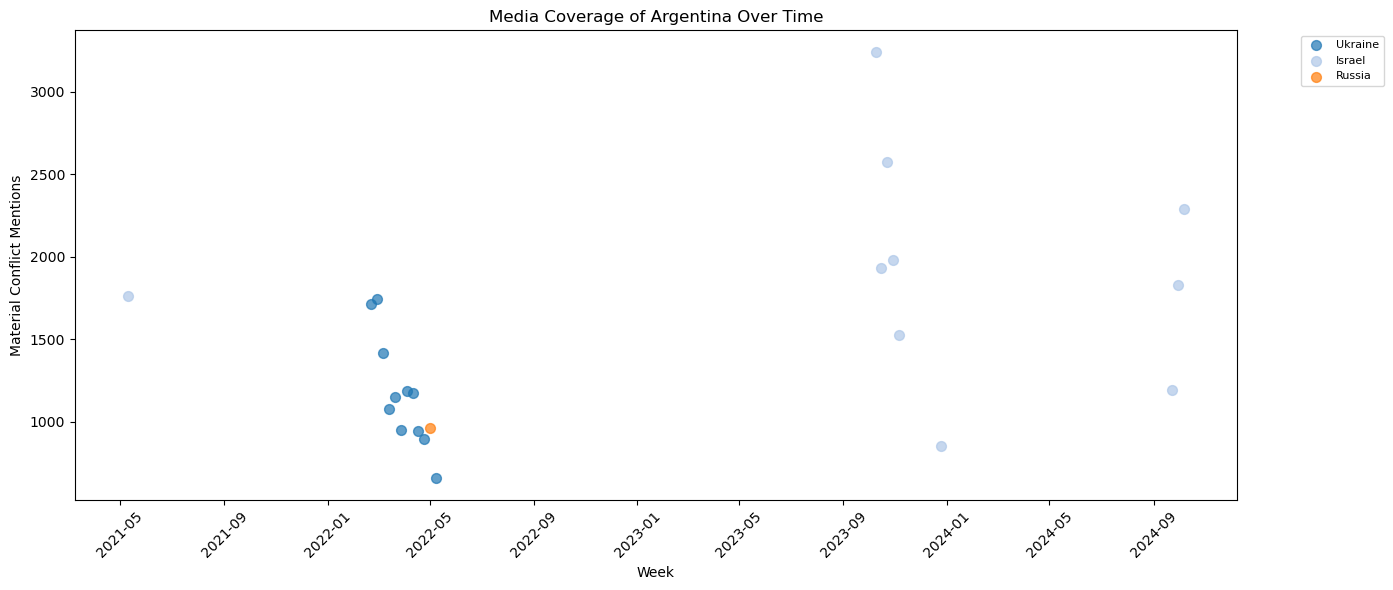

In [47]:
# Scatter plot with matplotlib of media_coverage['Argentina'] with x as week and y as mentions and color as country_name
weeks = []
mentions = []
country_names = []
for week, data in media_coverage['Italy'].items():
    if data != {}:  # Only include non-empty data
        weeks.append(week)
        mentions.append(data['mentions'])
        country_names.append(data['country_name'])

# Convert weeks to datetime for better plotting
weeks_dt = pd.to_datetime(weeks)

plt.figure(figsize=(14, 6))
unique_countries = list(set(country_names))
colors = plt.cm.tab20(range(len(unique_countries)))
color_map = {country: colors[i] for i, country in enumerate(unique_countries)}

for country in unique_countries:
    indices = [i for i, c in enumerate(country_names) if c == country]
    plt.scatter([weeks_dt[i] for i in indices], [mentions[i] for i in indices], 
                label=country, s=50, alpha=0.7, color=color_map[country])

plt.xlabel('Week')
plt.ylabel('Material Conflict Mentions')
plt.title('Media Coverage of Argentina Over Time')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


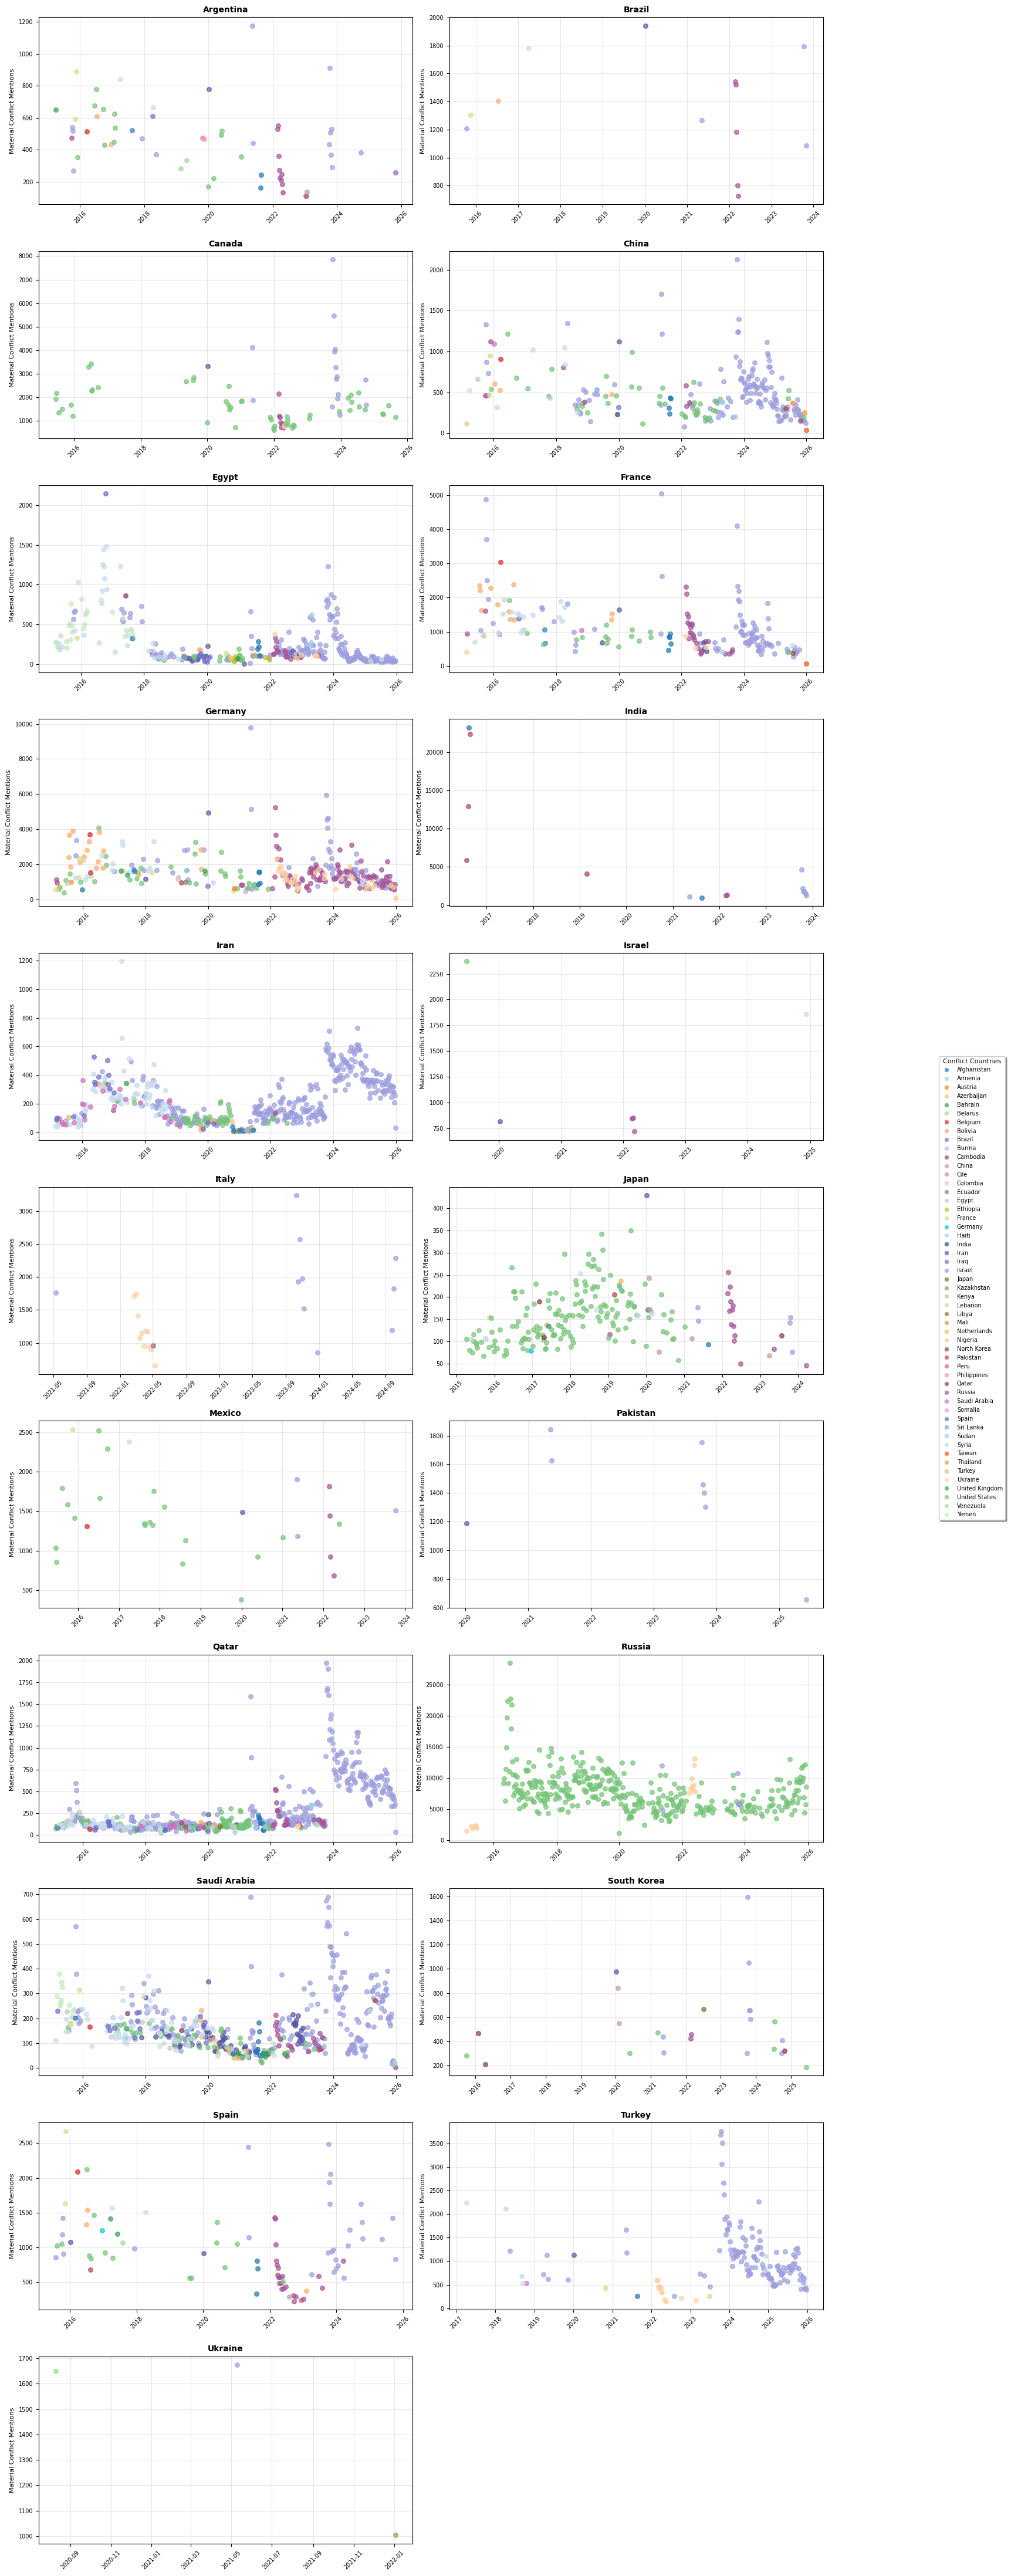

In [54]:
# Count actual countries to plot (excluding the 3 skipped ones)
countries_to_plot = [mc for mc in media_countries 
                     if mc not in ['LatAm (Left-Wing Block)', 'Other', 'Pan-Africa']]

# First pass: check which countries actually have data
countries_with_data = []
all_countries = set()

for media_country in countries_to_plot:
    country_key = media_country
    if media_country == 'UAE':
        country_key = 'United Arab Emirates'
    elif media_country == 'UK':
        country_key = 'United Kingdom'
    elif media_country == 'USA':
        country_key = 'United States'
    
    has_data = False
    for week, data in media_coverage[country_key].items():
        if data != {}:
            has_data = True
            all_countries.add(data['country_name'])
    
    if has_data:
        countries_with_data.append(media_country)

n_countries = len(countries_with_data)

# Calculate grid size needed
n_cols = 2
n_rows = (n_countries + n_cols - 1) // n_cols  # Ceiling division

# Create the grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
if n_rows == 1:
    axes = [axes] if n_cols == 1 else axes
else:
    axes = axes.flatten()

# Create diverse color map with enough colors
all_countries = sorted(list(all_countries))
n_colors = len(all_countries)

# Use multiple color maps to get distinct colors
if n_colors <= 20:
    colors = plt.cm.tab20(range(n_colors))
else:
    # Combine multiple colormaps for more distinct colors
    colors1 = plt.cm.tab20(range(20))
    colors2 = plt.cm.tab20b(range(min(20, n_colors - 20)))
    colors3 = plt.cm.tab20c(range(max(0, n_colors - 40)))
    colors = list(colors1) + list(colors2) + list(colors3)
    colors = colors[:n_colors]

color_map = {country: colors[i] for i, country in enumerate(all_countries)}

# Plot each media country that has data
idx = 0
for media_country in countries_with_data:
    country_key = media_country
    if media_country == 'UAE':
        country_key = 'United Arab Emirates'
    elif media_country == 'UK':
        country_key = 'United Kingdom'
    elif media_country == 'USA':
        country_key = 'United States'
    
    weeks = []
    mentions = []
    country_names = []
    for week, data in media_coverage[country_key].items():
        if data != {}:
            weeks.append(week)
            mentions.append(data['mentions'])
            country_names.append(data['country_name'])
    
    weeks_dt = pd.to_datetime(weeks)
    ax = axes[idx]
    
    unique_countries = list(set(country_names))
    
    for country in unique_countries:
        indices = [i for i, c in enumerate(country_names) if c == country]
        ax.scatter([weeks_dt[i] for i in indices], [mentions[i] for i in indices], 
                   s=30, alpha=0.7, color=color_map[country])
    
    ax.set_title(f'{country_key}', fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_ylabel('Material Conflict Mentions', fontsize=8)
    ax.grid(True, alpha=0.3)
    
    idx += 1

# Hide unused subplots (if any)
for i in range(idx, len(axes)):
    axes[i].set_visible(False)

# Create shared legend with smaller font if many countries
legend_fontsize = 7 if n_colors > 30 else 8
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                      markerfacecolor=color_map[country], 
                      markersize=6, alpha=0.7, label=country) 
           for country in all_countries]

fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5), 
           fontsize=legend_fontsize, title='Conflict Countries', 
           title_fontsize=legend_fontsize+1, frameon=True, 
           fancybox=True, shadow=True)

plt.tight_layout()
plt.subplots_adjust(right=0.88)  # Make space for legend
plt.show()

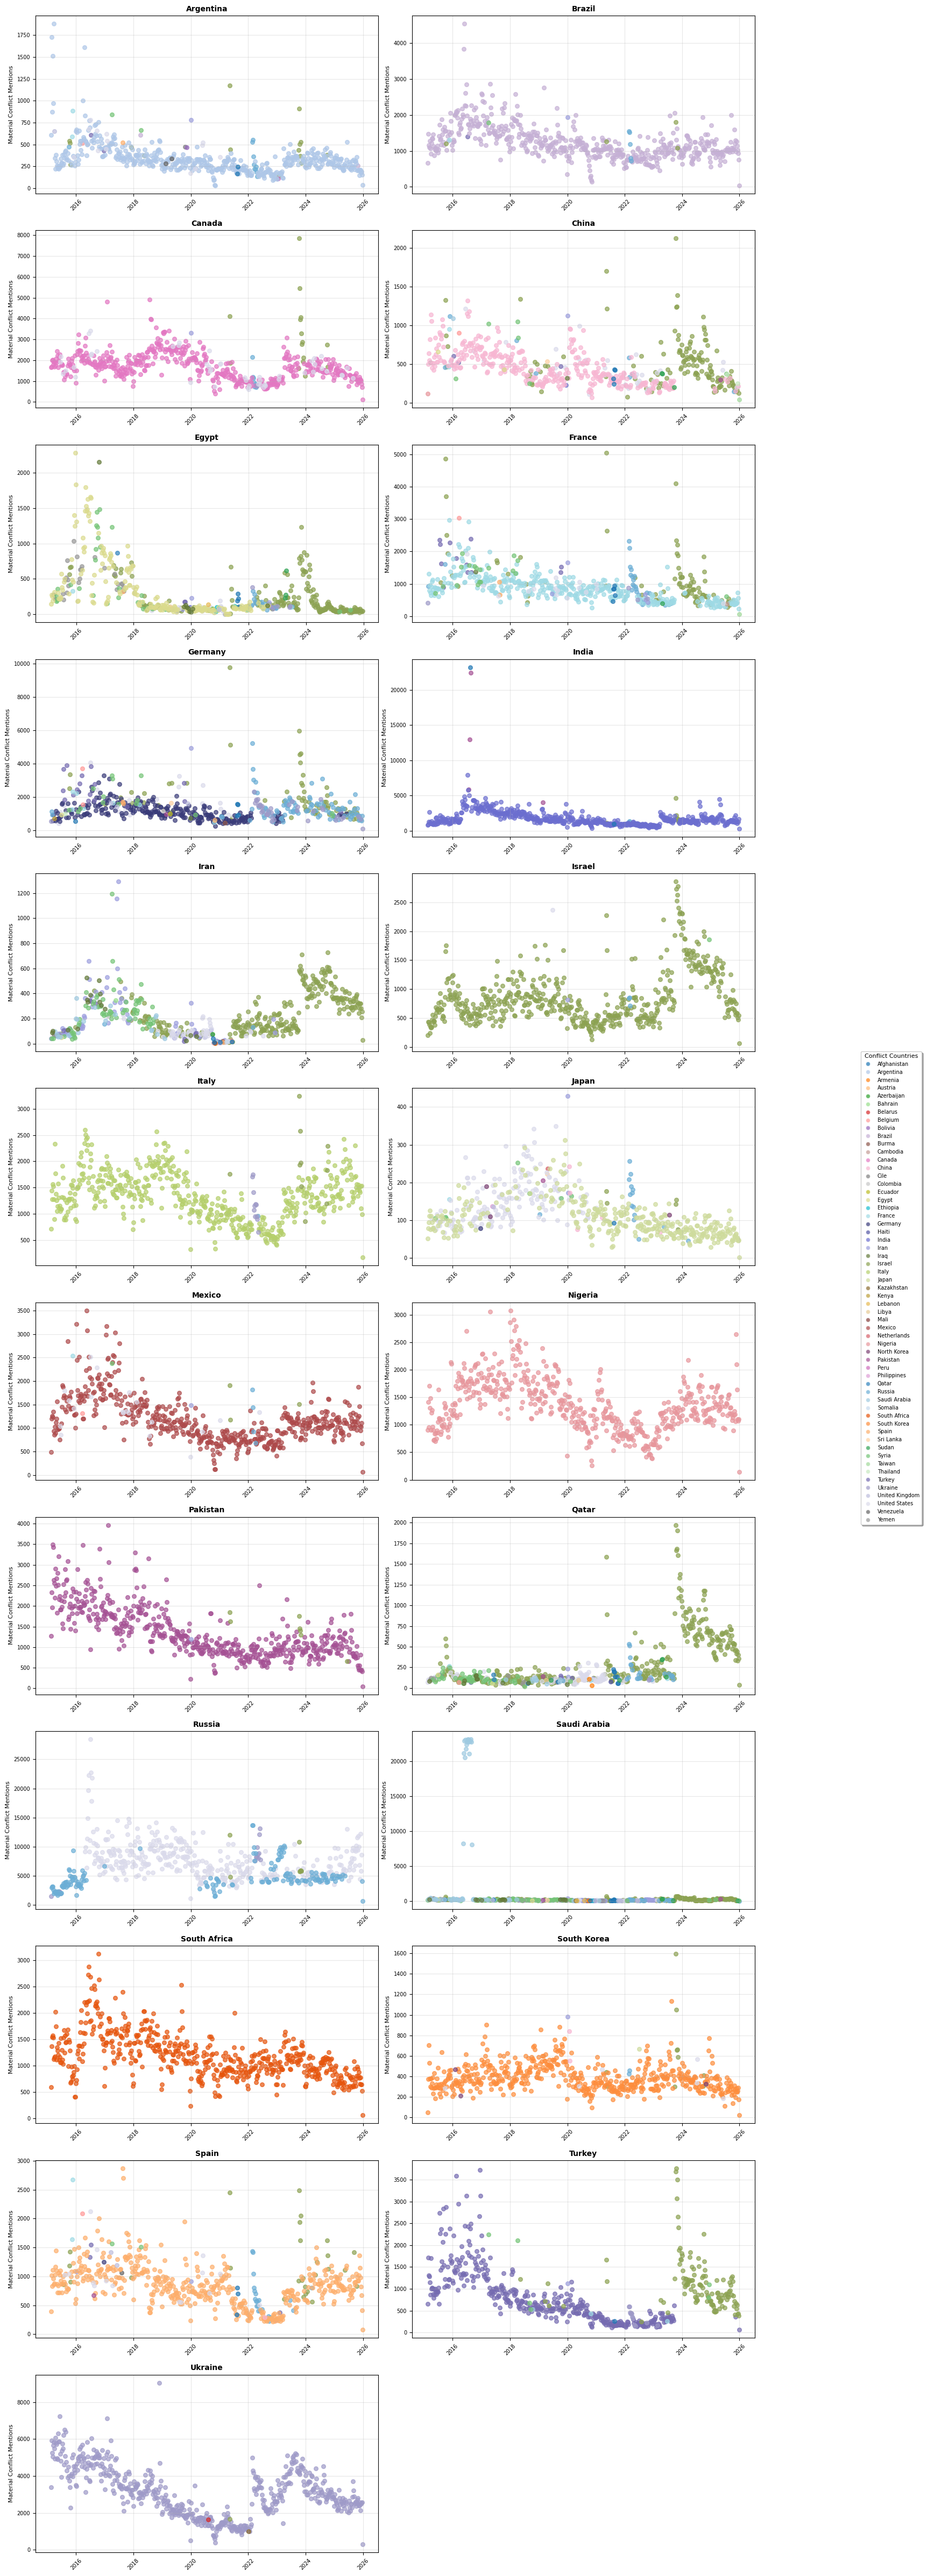

In [56]:
# Count actual countries to plot (excluding the 3 skipped ones)
countries_to_plot = [mc for mc in media_countries 
                     if mc not in ['LatAm (Left-Wing Block)', 'Other', 'Pan-Africa']]

# First pass: check which countries actually have data
countries_with_data = []
all_countries = set()

for media_country in countries_to_plot:
    country_key = media_country
    if media_country == 'UAE':
        country_key = 'United Arab Emirates'
    elif media_country == 'UK':
        country_key = 'United Kingdom'
    elif media_country == 'USA':
        country_key = 'United States'
    
    has_data = False
    for week, data in media_coverage_total[country_key].items():
        if data != {}:
            has_data = True
            all_countries.add(data['country_name'])
    
    if has_data:
        countries_with_data.append(media_country)

n_countries = len(countries_with_data)

# Calculate grid size needed
n_cols = 2
n_rows = (n_countries + n_cols - 1) // n_cols  # Ceiling division

# Create the grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
if n_rows == 1:
    axes = [axes] if n_cols == 1 else axes
else:
    axes = axes.flatten()

# Create diverse color map with enough colors
all_countries = sorted(list(all_countries))
n_colors = len(all_countries)

# Use multiple color maps to get distinct colors
if n_colors <= 20:
    colors = plt.cm.tab20(range(n_colors))
else:
    # Combine multiple colormaps for more distinct colors
    colors1 = plt.cm.tab20(range(20))
    colors2 = plt.cm.tab20b(range(min(20, n_colors - 20)))
    colors3 = plt.cm.tab20c(range(max(0, n_colors - 40)))
    colors = list(colors1) + list(colors2) + list(colors3)
    colors = colors[:n_colors]

color_map = {country: colors[i] for i, country in enumerate(all_countries)}

# Plot each media country that has data
idx = 0
for media_country in countries_with_data:
    country_key = media_country
    if media_country == 'UAE':
        country_key = 'United Arab Emirates'
    elif media_country == 'UK':
        country_key = 'United Kingdom'
    elif media_country == 'USA':
        country_key = 'United States'
    
    weeks = []
    mentions = []
    country_names = []
    for week, data in media_coverage_total[country_key].items():
        if data != {}:
            weeks.append(week)
            mentions.append(data['mentions'])
            country_names.append(data['country_name'])
    
    weeks_dt = pd.to_datetime(weeks)
    ax = axes[idx]
    
    unique_countries = list(set(country_names))
    
    for country in unique_countries:
        indices = [i for i, c in enumerate(country_names) if c == country]
        ax.scatter([weeks_dt[i] for i in indices], [mentions[i] for i in indices], 
                   s=30, alpha=0.7, color=color_map[country])
    
    ax.set_title(f'{country_key}', fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_ylabel('Material Conflict Mentions', fontsize=8)
    ax.grid(True, alpha=0.3)
    
    idx += 1

# Hide unused subplots (if any)
for i in range(idx, len(axes)):
    axes[i].set_visible(False)

# Create shared legend with smaller font if many countries
legend_fontsize = 7 if n_colors > 30 else 8
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                      markerfacecolor=color_map[country], 
                      markersize=6, alpha=0.7, label=country) 
           for country in all_countries]

fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5), 
           fontsize=legend_fontsize, title='Conflict Countries', 
           title_fontsize=legend_fontsize+1, frameon=True, 
           fancybox=True, shadow=True)

plt.tight_layout()
plt.subplots_adjust(right=0.88)  # Make space for legend
plt.show()

In [58]:
# Load the json file 'world.json' from '../src/json/world.json'
import json
with open('../src/json/world.json') as f:
    world_data = json.load(f)
    

In [59]:
# List all country names in the geojson file
geojson_countries = []
for feature in world_data['features']:
    country_name = feature['properties']['name']
    geojson_countries.append(country_name)
print(geojson_countries)

['Afghanistan', 'Angola', 'Albania', 'United Arab Emirates', 'Argentina', 'Armenia', 'Antarctica', 'French Southern and Antarctic Lands', 'Australia', 'Austria', 'Azerbaijan', 'Burundi', 'Belgium', 'Benin', 'Burkina Faso', 'Bangladesh', 'Bulgaria', 'The Bahamas', 'Bosnia and Herzegovina', 'Belarus', 'Belize', 'Bolivia', 'Brazil', 'Brunei', 'Bhutan', 'Botswana', 'Central African Republic', 'Canada', 'Switzerland', 'Chile', 'China', 'Ivory Coast', 'Cameroon', 'Democratic Republic of the Congo', 'Republic of the Congo', 'Colombia', 'Costa Rica', 'Cuba', 'Northern Cyprus', 'Cyprus', 'Czech Republic', 'Germany', 'Djibouti', 'Denmark', 'Dominican Republic', 'Algeria', 'Ecuador', 'Egypt', 'Eritrea', 'Spain', 'Estonia', 'Ethiopia', 'Finland', 'Fiji', 'Falkland Islands', 'France', 'Gabon', 'England', 'Georgia', 'Ghana', 'Guinea', 'Gambia', 'Guinea Bissau', 'Equatorial Guinea', 'Greece', 'Greenland', 'Guatemala', 'Guyana', 'Honduras', 'Croatia', 'Haiti', 'Hungary', 'Indonesia', 'India', 'Ireland

In [ ]:
df_top_mentions.head()

,mention_week,conflict_country_name,media_country,material_conflict_mentions,material_conflict_unique_events
997283,2015-02-16,Argentina,Argentina,610,186
996959,2015-02-16,Sweden,Argentina,321,30
996057,2015-02-16,Iran,Argentina,174,49
996062,2015-02-16,Brazil,Brazil,667,381
997050,2015-02-16,Ukraine,Brazil,231,84


In [70]:
# List all country names in df_top_mentions['media_country']
ccns = df_top_mentions['media_country'].unique()
print(ccns)

['Argentina' 'Brazil' 'Canada' 'China' 'Egypt' 'France' 'Germany' 'India'
 'Iran' 'Israel' 'Italy' 'Japan' 'LatAm (Left-Wing Block)' 'Mexico'
 'Nigeria' 'Other' 'Pakistan' 'Pan-Africa' 'Qatar' 'Russia' 'Saudi Arabia'
 'South Africa' 'South Korea' 'Spain' 'Turkey' 'United Arab Emirates'
 'England' 'USA' 'Ukraine']


In [71]:
# Find which country names in media_coverage are not in geojson_countries
missing_countries_json = []
for country in ccns:
    if country not in geojson_countries:
        missing_countries_json.append(country)

print(missing_countries_json)

# Convert 'UK' to 'England' and 'UAE' to 'United Arab Emirates' in the column 'media_country' of df_top_mentions
df_top_mentions['media_country'] = df_top_mentions['media_country'].replace({'UK': 'England', 'UAE': 'United Arab Emirates'})

['LatAm (Left-Wing Block)', 'Other', 'Pan-Africa']


In [ ]:
# Save as csv df_top_mentions
#output_path = "../data/processed/top_three_media_mentions_by_country_week_material_conflict.csv"
#df_top_mentions.to_csv(output_path, index=False)